In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D as ax
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

In [2]:
N_components = 0.85

# Pulizia

In [3]:
df = pd.read_csv('rsc/student_data.csv')

print(df.head())
print(df.describe())
df.info()

print(df.columns)
print(df.isnull().sum().sum())

# cerchiamo i duplicati
print(df.duplicated().sum())



  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
              age        Medu        Fedu  traveltime   studytime    failures  \
count  

# Preprocessing

school: 2 unique values
sex: 2 unique values
address: 2 unique values
famsize: 2 unique values
Pstatus: 2 unique values
Mjob: 5 unique values
Fjob: 5 unique values
reason: 4 unique values
guardian: 3 unique values
schoolsup: 2 unique values
famsup: 2 unique values
paid: 2 unique values
activities: 2 unique values
nursery: 2 unique values
higher: 2 unique values
internet: 2 unique values
romantic: 2 unique values
Numero di componenti principali: 22


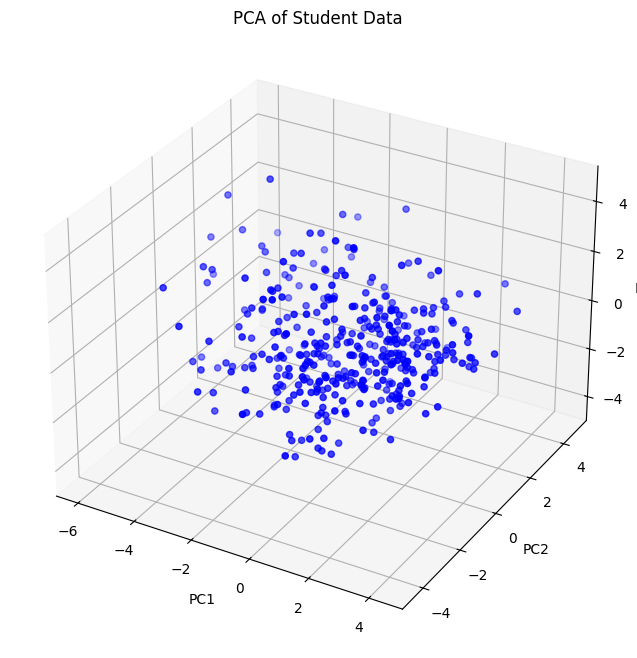

In [4]:
# controlliamo il numero di valori unici per ogni colonna categorica. non ha senso fare il label encoder su colonne con valori tutti uguali o tutti diversi
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

# usiamo il label encoder per convertire le colonne categoriche in numeriche
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


# PCA per ridurre la dimensionalità
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
pca = PCA(n_components=N_components)
pca_data = pca.fit_transform(scaled_data)

# numero di componenti principali
print(f"Numero di componenti principali: {pca.n_components_}")

# Visualizzazione dei dati PCA in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:, 0], pca_data[:, 1], pca_data[:, 2], c='blue', marker='o')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA of Student Data')
plt.show()


# K-Means

Silhouette score for 2 clusters: 0.08913793196307424 inertia: 10278.75023248085
Silhouette score for 3 clusters: 0.07056310103676493 inertia: 9766.181385650858
Silhouette score for 4 clusters: 0.052911995753524295 inertia: 9392.919075491802
Silhouette score for 5 clusters: 0.04808264843763109 inertia: 9077.105390672945
Silhouette score for 6 clusters: 0.05859832130032129 inertia: 8749.869459536696
Silhouette score for 7 clusters: 0.050337329451860015 inertia: 8587.948572454465
Silhouette score for 8 clusters: 0.05745890766212997 inertia: 8318.271875289136
Silhouette score for 9 clusters: 0.06420798748666241 inertia: 8091.739845526159
Silhouette score for 10 clusters: 0.06596825363638857 inertia: 7945.645418435579
Silhouette score for 11 clusters: 0.06350750874210583 inertia: 7836.275867235128
Silhouette score for 12 clusters: 0.05644556145263058 inertia: 7723.961695279353
Silhouette score for 13 clusters: 0.05601850991351553 inertia: 7604.954947695949
Silhouette score for 14 clusters: 

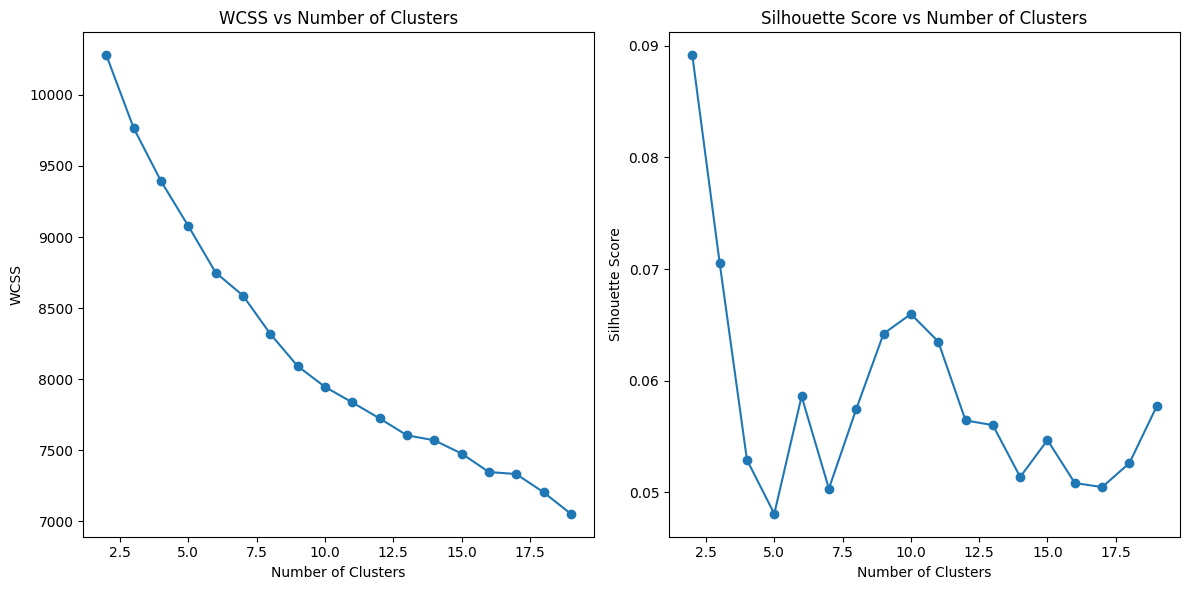

In [5]:
wcss = []
for i in range(2, 20):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pca_data)
    silhouette_avg = silhouette_score(pca_data, kmeans.labels_)
    print(f"Silhouette score for {i} clusters: {silhouette_avg} inertia: {kmeans.inertia_}")
    wcss.append(kmeans.inertia_)

# plotting inetia e silhouette scores affiancati
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, 20), wcss, marker='o')
plt.title('WCSS vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.subplot(1, 2, 2)
plt.plot(range(2, 20), [silhouette_score(pca_data, KMeans(n_clusters=i, random_state=42).fit(pca_data).labels_) for i in range(2, 20)], marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


In [ ]:
# assegniamo le labels del kmeans al dataframe originale
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(pca_data)
df['Cluster'] = kmeans.labels_